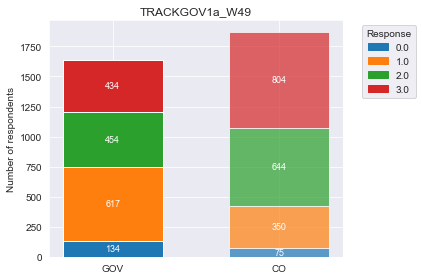

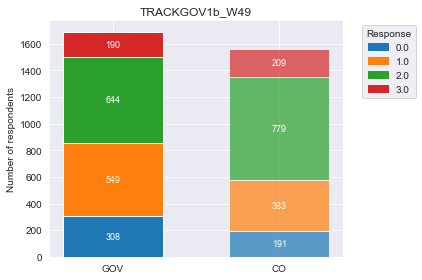

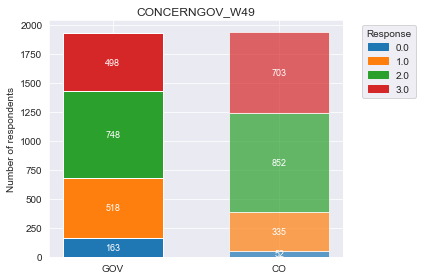

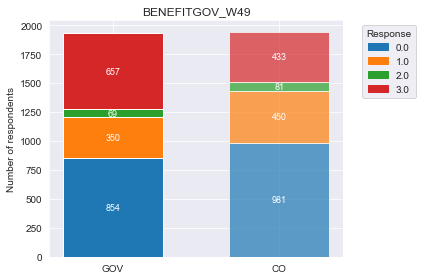

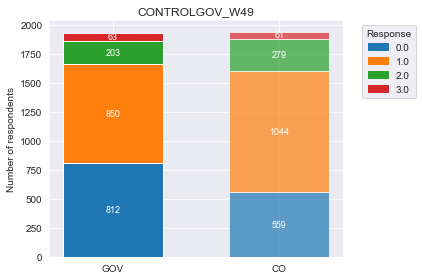

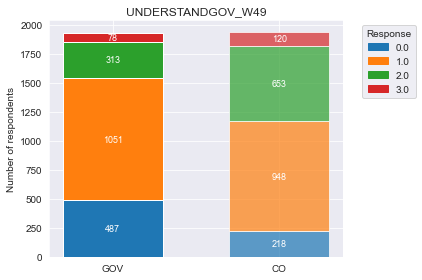

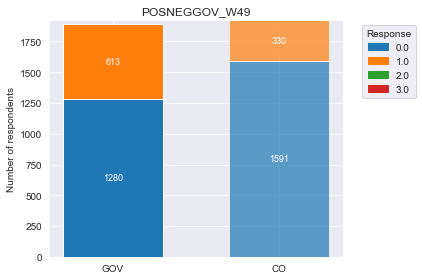

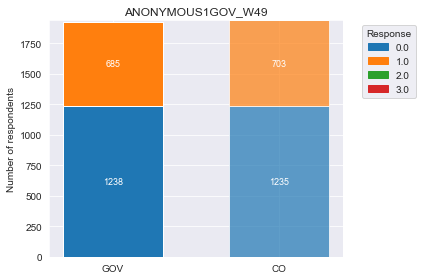

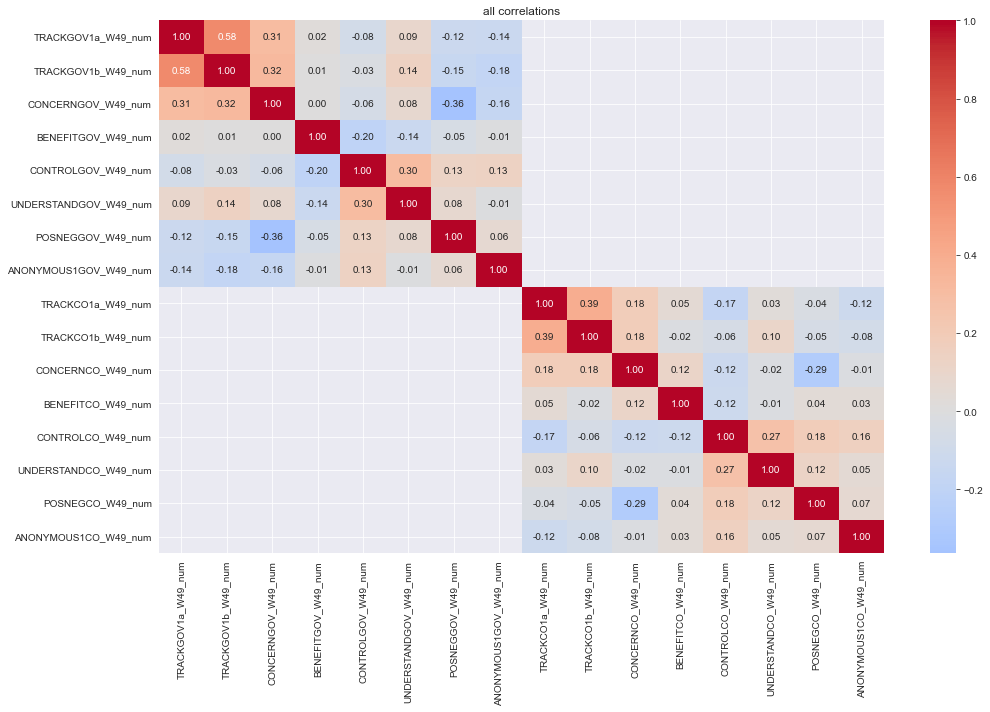

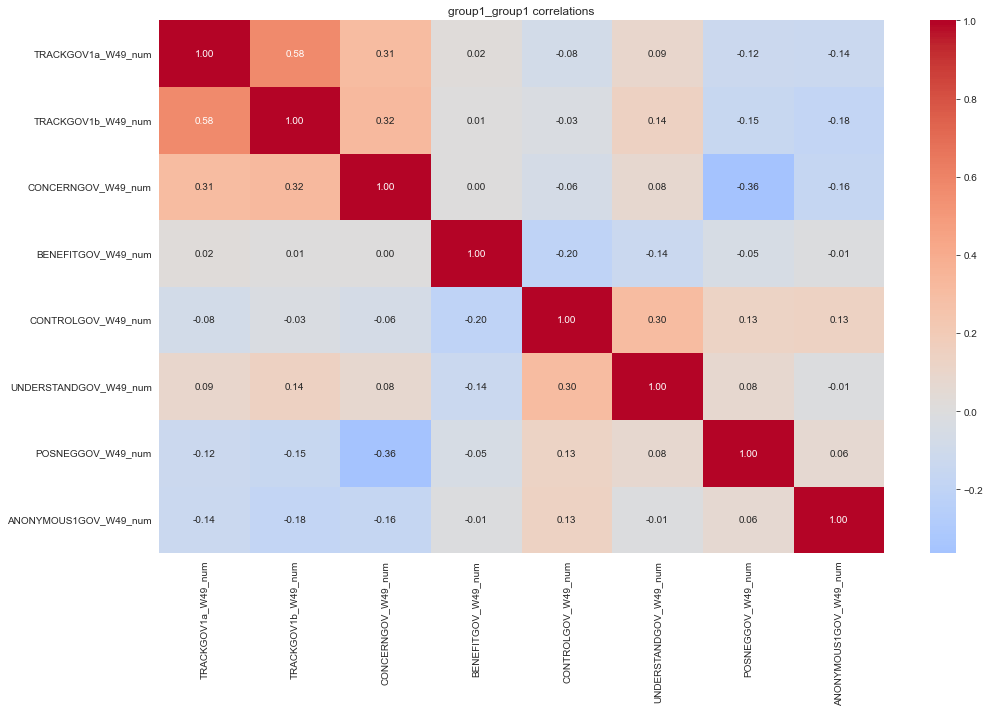

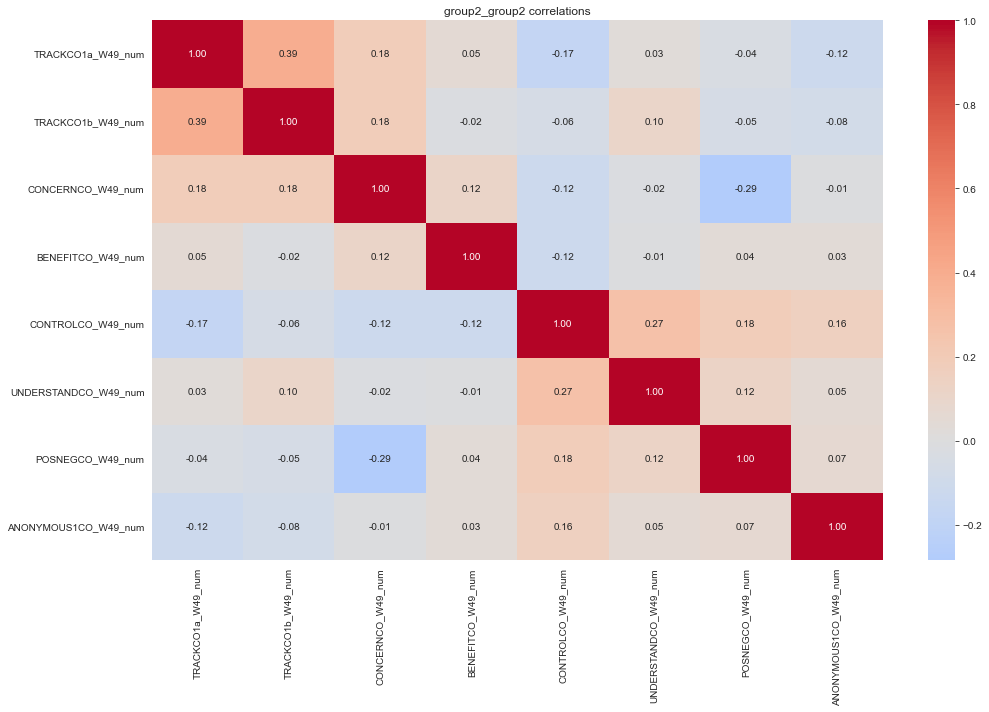

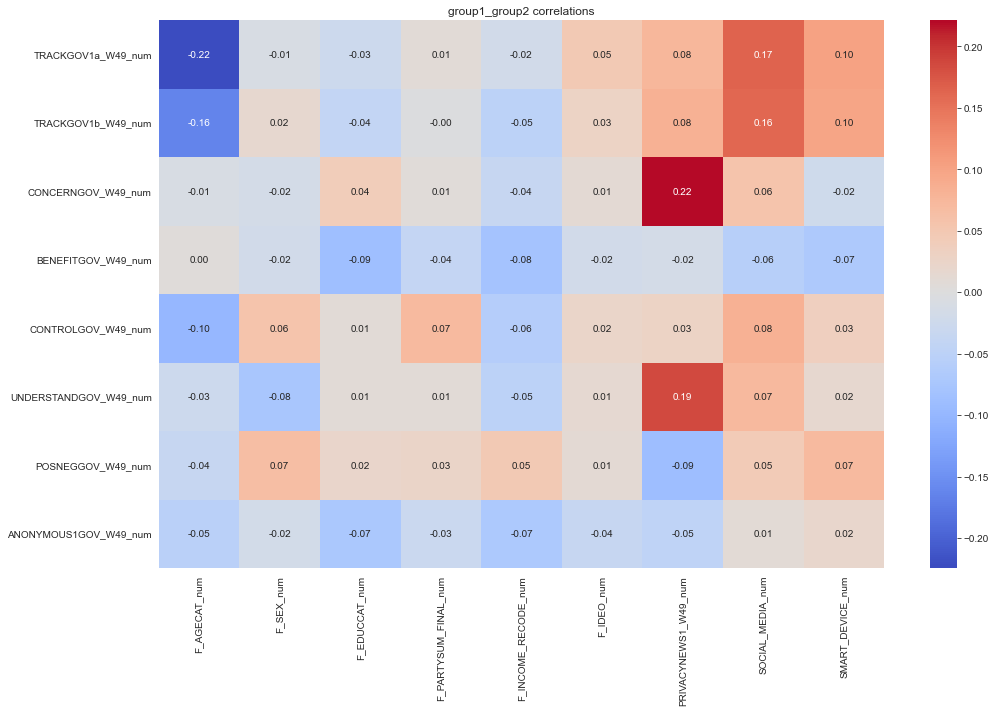

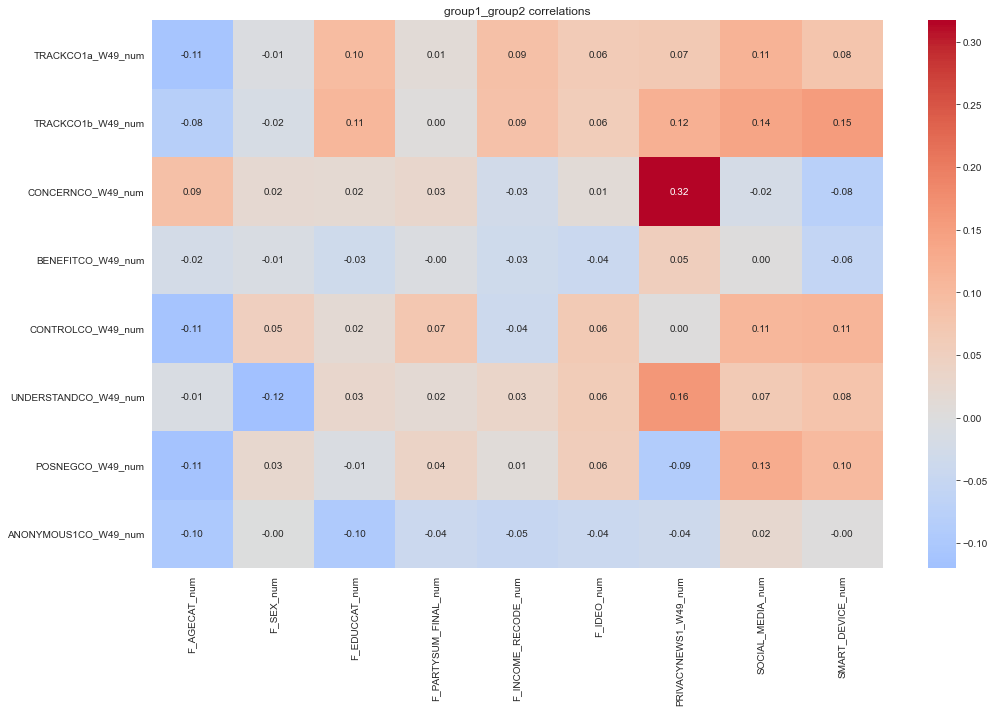

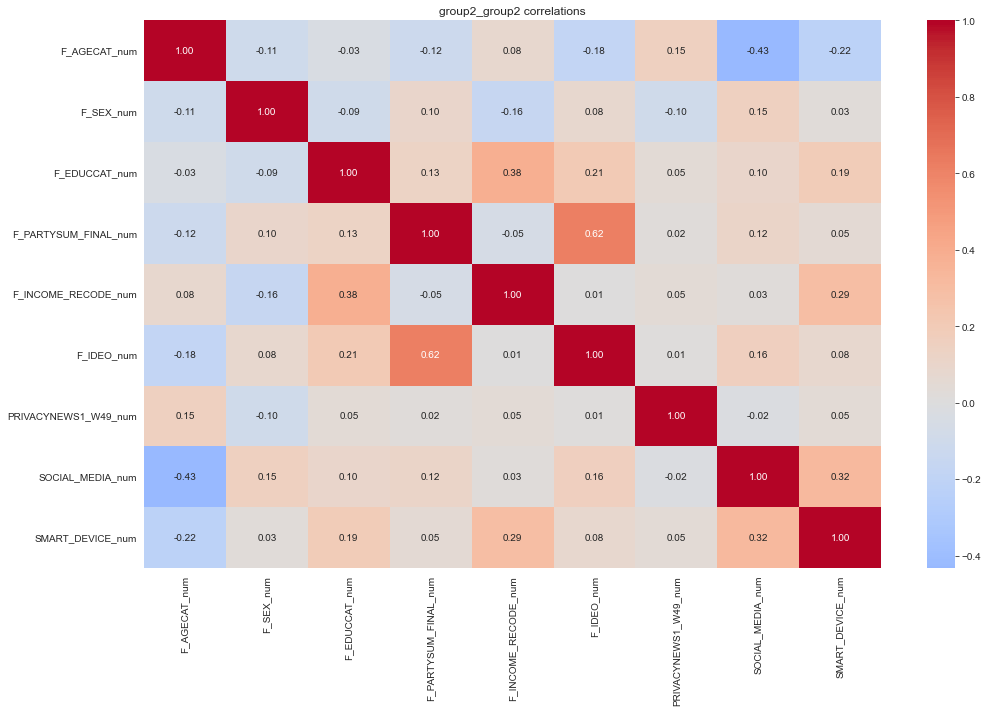

Ordinal logistic regression: Government benefit predicted by demographic variables
                             OrderedModel Results                             
Dep. Variable:     BENEFITGOV_W49_num   Log-Likelihood:                -2211.7
Model:                   OrderedModel   AIC:                             4447.
Method:            Maximum Likelihood   BIC:                             4514.
Date:                Thu, 09 Oct 2025                                         
Time:                        15:05:51                                         
No. Observations:                1925                                         
Df Residuals:                    1913                                         
Df Model:                           9                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
F_AGECAT_num            -0.0

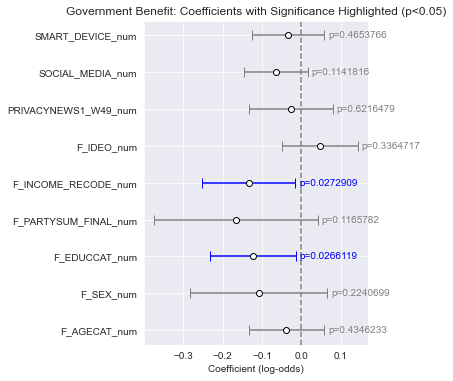

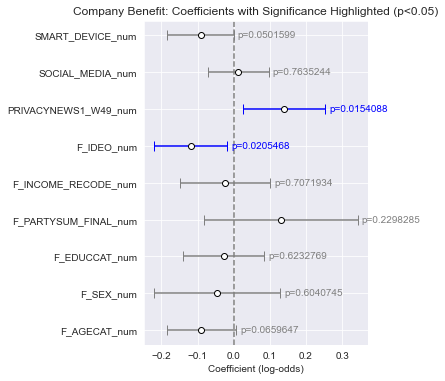

In [177]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
from statsmodels.miscmodels.ordinal_model import OrderedModel


# -----------------------------
# 1. Data Loading
# -----------------------------
def load_data(file_path, target_cols):
    """Load dataset and keep only target columns plus QKEY."""
    df = pd.read_csv(file_path)
    cols_to_keep = ["QKEY"] + target_cols
    return df[cols_to_keep].replace([np.inf, -np.inf], np.nan)

# -----------------------------
# 2. Variable Definitions
# -----------------------------
def define_variable_groups():
    """Return grouped variable names for government and company sections."""
    government = [
        "TRACKGOV1a_W49_num",  # Everything tracked vs nothing tracked
        "TRACKGOV1b_W49_num",
        "CONCERNGOV_W49_num",  # More concern vs less concern
        "BENEFITGOV_W49_num",  # More benefit vs less benefit
        "CONTROLGOV_W49_num",  # More control vs no control
        "UNDERSTANDGOV_W49_num", # Great understanding vs no understanding
        "POSNEGGOV_W49_num",   # Benefits outweigh risks vs do not
        "ANONYMOUS1GOV_W49_num" # Daily life without government possible vs not
    ]
    company = [
        "TRACKCO1a_W49_num",  # Everything tracked vs nothing tracked
        "TRACKCO1b_W49_num",
        "CONCERNCO_W49_num",  # More concern vs less concern
        "BENEFITCO_W49_num",  # More benefit vs less benefit
        "CONTROLCO_W49_num",  # More control vs no control
        "UNDERSTANDCO_W49_num", # Great understanding vs no understanding
        "POSNEGCO_W49_num",   # Benefits outweigh risks vs do not
        "ANONYMOUS1CO_W49_num" # Daily life without government possible vs not
    ]
    return government, company

def define_categories():
    """Return category definitions for grouped variable analysis with descriptions."""
    return {
        # Government-related categories
        'gov_benefit': ['BENEFITGOV_W49_num'],
        'gov_concern': ['CONCERNGOV_W49_num'],
        'gov_control': ['CONTROLGOV_W49_num'],
        'gov_understanding': ['UNDERSTANDGOV_W49_num'],
        'gov_tracking': ['TRACKGOV1a_W49_num','TRACKGOV1b_W49_num'],

        # Company-related categories
        'com_benefit': ['BENEFITCO_W49_num'],
        'com_concern': ['CONCERNCO_W49_num'],
        'com_control': ['CONTROLCO_W49_num'],
        'com_understanding': ['UNDERSTANDCO_W49_num'],
        'com_tracking': ['TRACKCO1a_W49_num','TRACKCO1b_W49_num'],
    }

# -----------------------------
# 3. Demographic Processing
# -----------------------------
def process_demographics(df):
    """
    Convert demographic string variables to numeric categorical codes for correlation analysis.
    Drop any rows where demographic values are DK/REF or Refused.

    Mapping:
    F_SEX: Male=1, Female=2
    F_AGECAT: 18-29=1, 30-49=2, 50-64=3, 65+=4, DK/REF=5
    F_EDUCCAT: H.S. graduate or less=1, Some College=2, College graduate+=3, Don't know/Refused=4
    F_PARTYSUM_FINAL: Rep/Lean Rep=1, Dem/Lean Dem=2, DK/Refused/No lean=3
    F_INCOME_RECODE: <$30,000=1, $30-$74,999=2, $75,000+=3, Don't know/Refused=4
    F_IDEO: Very conservative=1, Conservative=2, Moderate=3, Liberal=4, Very liberal=5, Refused=6
    """
    sex_map = {'Male': 1, 'Female': 2}
    age_map = {'18-29': 1, '30-49': 2, '50-64': 3, '65+': 4, 'DK/REF': 5}
    edu_map = {'H.S. graduate or less': 1, 'Some College': 2, 'College graduate+': 3, "Don't know/Refused": 4}
    party_map = {'Rep/Lean Rep': 1, 'Dem/Lean Dem': 2, 'DK/Refused/No lean': 3}
    income_map = {'<$30,000': 1, '$30-$74,999': 2, '$75,000+': 3, "Don't know/Refused": 4}
    ideo_map = {'Very conservative': 1, 'Conservative': 2, 'Moderate': 3, 'Liberal': 4, 'Very liberal': 5, 'Refused': 6}

    df = df.copy()
    df['F_SEX_num'] = df['F_SEX'].map(sex_map)
    df['F_AGECAT_num'] = df['F_AGECAT'].map(age_map)
    df['F_EDUCCAT_num'] = df['F_EDUCCAT'].map(edu_map)
    df['F_PARTYSUM_FINAL_num'] = df['F_PARTYSUM_FINAL'].map(party_map)
    df['F_INCOME_RECODE_num'] = df['F_INCOME_RECODE'].map(income_map)
    df['F_IDEO_num'] = df['F_IDEO'].map(ideo_map)

    # --------------------------
    # Drop rows with any Refused/DK/REF values
    # F_AGECAT_num == 5, F_EDUCCAT_num == 4, F_PARTYSUM_FINAL_num == 3,
    # F_INCOME_RECODE_num == 4, F_IDEO_num == 6
    # --------------------------
    df = df[
        (df['F_AGECAT_num'] != 5) &
        (df['F_EDUCCAT_num'] != 4) &
        (df['F_PARTYSUM_FINAL_num'] != 3) &
        (df['F_INCOME_RECODE_num'] != 4) &
        (df['F_IDEO_num'] != 6)
    ].copy()


    # Baseline-related categories non-demographic
    # --- Create SOCIAL_MEDIA_num ---
    social_media_cols = [
        'SOCMEDIAUSEa_W49_num',
        'SOCMEDIAUSEb_W49_num',
        'SOCMEDIAUSEc_W49_num',
        'SOCMEDIAUSEd_W49_num'
    ]

    # Count how many "1.0" (Yes) responses per row
    df['SOCIAL_MEDIA_num'] = df[social_media_cols].sum(axis=1) + 1

    # print("\nSOCIAL_MEDIA_num distribution:")
    # print(df['SOCIAL_MEDIA_num'].value_counts(dropna=False).sort_index())

    smart_device_cols = [
        'HOMEIOT_W49_num',
        'HOMEASSIST1_W49_num',
        'FITTRACK_W49_num',
        'SMARTPHONE_W49_num',
    ]

    # Count how many "1.0" (Yes) responses per row
    df['SMART_DEVICE_num'] = df[smart_device_cols].sum(axis=1) + 1

    return df


# -----------------------------
# 4. Correlations
# -----------------------------
def compute_spearman_correlations(df, group1, group2):
    """Compute Spearman correlations and extract relevant blocks."""
    corr = df[group1 + group2].corr(method='spearman')
    return {
        'all': corr,
        'group1_group1': corr.loc[group1, group1],
        'group2_group2': corr.loc[group2, group2],
        'group1_group2': corr.loc[group1, group2]
    }

def compute_category_correlations(df, categories):
    """Compute average Spearman correlations between category groups."""
    all_items = sum(categories.values(), [])
    df[all_items] = df[all_items].apply(pd.to_numeric, errors='coerce')

    category_names = list(categories.keys())
    category_matrix = pd.DataFrame(index=category_names, columns=category_names, dtype=float)

    for cat1 in category_names:
        for cat2 in category_names:
            items1, items2 = categories[cat1], categories[cat2]
            rhos = []
            for i in items1:
                for j in items2:
                    valid = df[[i, j]].dropna()
                    if len(valid) > 2:
                        rho, _ = spearmanr(valid[i], valid[j])
                        if isinstance(rho, (np.ndarray, list)):
                            try:
                                rho = rho[0, 1]
                            except Exception:
                                rho = np.nan
                        if isinstance(rho, (int, float, np.floating)) and not np.isnan(rho):
                            rhos.append(rho)
            category_matrix.loc[cat1, cat2] = np.mean(rhos) if rhos else np.nan

    return category_matrix

# -----------------------------
# 5. Visualization
# -----------------------------
def plot_all_gov_co_with_legend(df):
    """
    Plot GOV vs CO responses for all matched questions, one plot per question,
    with a single legend showing response values. Titles indicate which is left/right.
    """
    # Define column pairs
    gov_cols = ["TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num", "BENEFITGOV_W49_num",
                "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num", "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num"]
    co_cols  = ["TRACKCO1a_W49_num", "TRACKCO1b_W49_num", "CONCERNCO_W49_num", "BENEFITCO_W49_num",
                "CONTROLCO_W49_num", "UNDERSTANDCO_W49_num", "POSNEGCO_W49_num", "ANONYMOUS1CO_W49_num"]

    question_labels = [col.replace("_num", "") for col in gov_cols]

    # Determine all possible responses across all columns
    all_values = sorted(pd.concat([df[gov_cols + co_cols].stack()]).dropna().unique())
    colors = plt.cm.tab10.colors[:len(all_values)]
    value_color_map = {val: colors[i] for i, val in enumerate(all_values)}

    for gov_col, co_col, label in zip(gov_cols, co_cols, question_labels):
        x = np.arange(2)  # GOV vs CO
        width = 0.6

        gov_counts = [df[gov_col].eq(val).sum() for val in all_values]
        co_counts  = [df[co_col].eq(val).sum() for val in all_values]

        fig, ax = plt.subplots(figsize=(6, 4))
        bottoms_gov = 0
        bottoms_co  = 0
        for val_idx, val in enumerate(all_values):
            ax.bar(x[0], gov_counts[val_idx], width, bottom=bottoms_gov, color=colors[val_idx])
            bottoms_gov += gov_counts[val_idx]
            ax.bar(x[1], co_counts[val_idx], width, bottom=bottoms_co, color=colors[val_idx], alpha=0.7)
            bottoms_co += co_counts[val_idx]

            # Add counts on top of each bar segment
            if gov_counts[val_idx] > 0:
                ax.text(x[0], bottoms_gov - gov_counts[val_idx]/2, str(gov_counts[val_idx]),
                        ha='center', va='center', color='white', fontsize=9)
            if co_counts[val_idx] > 0:
                ax.text(x[1], bottoms_co - co_counts[val_idx]/2, str(co_counts[val_idx]),
                        ha='center', va='center', color='white', fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(["GOV", "CO"])
        ax.set_ylabel("Number of respondents")
        ax.set_title(f"{label} (Left = GOV, Right = CO)")

        # Add legend
        legend_labels = [f"{val}" for val in all_values]
        ax.legend(handles=[plt.Rectangle((0,0),1,1,color=value_color_map[val]) for val in all_values],
                  labels=legend_labels, title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()



def plot_heatmap(matrix, title, figsize=(15, 10), annot=True):
    """Plot a single heatmap for the given matrix."""
    plt.figure(figsize=figsize)
    sns.heatmap(matrix, annot=annot, fmt=".2f", cmap='coolwarm', center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_corr_blocks(corr_blocks, blocks_to_plot=None):
    """
    Plot selected correlation heatmaps.

    Parameters:
    - corr_blocks: dict returned by compute_spearman_correlations
    - blocks_to_plot: list of keys from corr_blocks to plot (e.g., ['all', 'group1_group2'])
                      If None, defaults to plotting all blocks.

    Usage:
    plot_corr_blocks(corr_blocks)  # plots all by default
    plot_corr_blocks(corr_blocks, blocks_to_plot=['group1_group1', 'group1_group2'])  # plots only specified blocks
    """
    if blocks_to_plot is None:
        blocks_to_plot = ['all', 'group1_group1', 'group2_group2', 'group1_group2']

    for block in blocks_to_plot:
        if block in corr_blocks:
            plot_heatmap(corr_blocks[block], f"{block} correlations")
        else:
            print(f"Warning: '{block}' not found in correlation blocks")

def plot_ordinal_with_significance(result, significance_level=0.05, title_prefix=""):
    coefs = result.params
    std_err = result.bse

    z_values = coefs / std_err
    p_values = pd.Series(2 * (1 - stats.norm.cdf(abs(z_values))), index=coefs.index)

    ci_low = coefs - 1.96 * std_err
    ci_high = coefs + 1.96 * std_err

    # Keep only predictors (exclude cut points)
    predictors = [var for var in coefs.index if '/' not in var]
    coefs = coefs[predictors]
    ci_low = ci_low[predictors]
    ci_high = ci_high[predictors]
    p_values = p_values[predictors]

    fig, ax = plt.subplots(figsize=(6, max(2, len(coefs)*0.6)))
    offset = 0.02 * (ci_high.max() - ci_low.min())

    for coef, low, high, p, idx in zip(coefs, ci_low, ci_high, p_values, coefs.index):
        color = 'blue' if p < significance_level else 'gray'
        ax.errorbar(coef, idx, xerr=[[coef - low], [high - coef]],
                    fmt='o', ecolor=color, capsize=5, mfc='white', mec='black')
        ax.text(high + offset, idx, f"p={p:.7f}", va='center', ha='left', color=color)


    ax.axvline(0, color='grey', linestyle='--')
    ax.set_xlabel("Coefficient (log-odds)")
    ax.set_title(f"{title_prefix}: Coefficients with Significance Highlighted (p<{significance_level})")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. Ordinal Logistic Regression
# -----------------------------
def fit_ordinal_benefit_model(df, outcome, predictors):
    model = OrderedModel(df[outcome], df[predictors], distr='logit')
    res = model.fit(method='bfgs', disp=False)
    return res

# -----------------------------
# 7. Main Execution
# -----------------------------
def main():
    # -------------------------
    # Targets & Demographics
    # -------------------------
    targets = [
        "TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num", "BENEFITGOV_W49_num",
        "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num", "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num",
        "TRACKCO1a_W49_num", "TRACKCO1b_W49_num", "CONCERNCO_W49_num", "BENEFITCO_W49_num",
        "CONTROLCO_W49_num", "UNDERSTANDCO_W49_num", "POSNEGCO_W49_num", "ANONYMOUS1CO_W49_num"
    ]

    demographics = [
        "F_AGECAT","F_SEX","F_EDUCCAT","F_PARTYSUM_FINAL","F_INCOME_RECODE","F_IDEO","F_RELIG",
        "PRIVACYNEWS1_W49_num", "SOCMEDIAUSEa_W49_num" ,"SOCMEDIAUSEb_W49_num","SOCMEDIAUSEc_W49_num",
        "SOCMEDIAUSEd_W49_num", 'HOMEIOT_W49_num','HOMEASSIST1_W49_num','FITTRACK_W49_num','SMARTPHONE_W49_num'
    ]

    demographics_num = [
        "F_AGECAT_num","F_SEX_num","F_EDUCCAT_num","F_PARTYSUM_FINAL_num","F_INCOME_RECODE_num",
        "F_IDEO_num", 'PRIVACYNEWS1_W49_num', "SOCIAL_MEDIA_num", "SMART_DEVICE_num"
    ]

    # -------------------------
    # Load & Clean Data
    # -------------------------
    df = pd.read_csv("data/full_survey_data_recoded_NEW.csv")
    df = process_demographics(df)

    # Replace NaN that should have been None in answers
    df.loc[df['BENEFITCO_W49_num'].isna() & df['CONCERNCO_W49_num'].notna(), 'BENEFITCO_W49_num'] = 3
    df.loc[df['BENEFITGOV_W49_num'].isna() & df['CONCERNGOV_W49_num'].notna(), 'BENEFITGOV_W49_num'] = 3

    # -------------------------
    # Define variable groups
    # -------------------------
    government, company = define_variable_groups()

    # -------------------------
    # Visualize differences
    # -------------------------

    gov_cols = ["TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num", "BENEFITGOV_W49_num",
            "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num", "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num"]
    co_cols = ["TRACKCO1a_W49_num", "TRACKCO1b_W49_num", "CONCERNCO_W49_num", "BENEFITCO_W49_num",
               "CONTROLCO_W49_num", "UNDERSTANDCO_W49_num", "POSNEGCO_W49_num", "ANONYMOUS1CO_W49_num"]

    plot_all_gov_co(df)

    # -------------------------
    # Compute correlations
    # -------------------------

    # Possible options form compute_spearman_correlations: blocks_to_plot = ['all', 'group1_group1', 'group2_group2', 'group1_group2']
    # Dus voor compute_spearman_correlations(df, government, company)
    # group1_group1 : government vs government
    # group2_group2: company vs company
    # group1_group2: government vs company

    corr_blocks = compute_spearman_correlations(df, government, company)
    plot_corr_blocks(corr_blocks, blocks_to_plot=['all','group1_group1', 'group2_group2'])

    corr_blocks_gov_demo = compute_spearman_correlations(df, government, demographics_num)
    plot_corr_blocks(corr_blocks_gov_demo, blocks_to_plot=['group1_group2'])

    corr_blocks_com_demo = compute_spearman_correlations(df, company, demographics_num)
    plot_corr_blocks(corr_blocks_com_demo, blocks_to_plot=['group1_group2'])

    corr_blocks_com_demo = compute_spearman_correlations(df, company, demographics_num)
    plot_corr_blocks(corr_blocks_com_demo, blocks_to_plot=['group2_group2'])


    # -------------------------
    # Ordinal logistic regressions
    # -------------------------
    #Government Benefit predicted by demographic variables
    df_clean = df.dropna(subset=["BENEFITGOV_W49_num"] + demographics_num).copy()
    res_gov_dem = fit_ordinal_benefit_model(df_clean, 'BENEFITGOV_W49_num', demographics_num)
    print("Ordinal logistic regression: Government benefit predicted by demographic variables")
    print(res_gov_dem.summary())

    # # Company concern predicted by demographic variables
    df_clean = df.dropna(subset=["BENEFITCO_W49_num"] + demographics_num).copy()
    res_com_dem = fit_ordinal_benefit_model(df_clean, 'BENEFITCO_W49_num', demographics_num)
    print("Ordinal logistic regression: Company benefit predicted by demographic variables")
    print(res_com_dem.summary())

    # Government Benefit ~ demographics
    plot_ordinal_with_significance(res_gov_dem, title_prefix="Government Benefit")

    # Company Benefit ~ demographics
    plot_ordinal_with_significance(res_com_dem, title_prefix="Company Benefit")

if __name__ == "__main__":
    main()
